# Question 1(a): Total Least Squares Line Fitting

Fit a line to the first line data (x1, y1) using Total Least Squares (TLS).

In [1]:
import numpy as np
import pandas as pd


In [2]:
# Load the data from lines.csv
df = pd.read_csv('lines.csv', skiprows=1, names=['x1', 'x2', 'x3', 'y1', 'y2', 'y3'])

# Extract x1 and y1 columns
x1 = df['x1'].values
y1 = df['y1'].values

print(f"Number of data points: {len(x1)}")
print(f"First 5 points:")
print(df[['x1', 'y1']].head())


Number of data points: 100
First 5 points:
         x1         y1
0 -5.305471 -12.666333
1 -5.540359 -11.007727
2 -4.982128 -11.697315
3 -4.495706 -11.978010
4 -4.442154 -12.414952


In [3]:
# Total Least Squares (TLS) fitting
# Center the data
x_mean = np.mean(x1)
y_mean = np.mean(y1)
x_centered = x1 - x_mean
y_centered = y1 - y_mean

# Construct the data matrix
A = np.column_stack([x_centered, y_centered])

# Perform SVD
U, S, Vt = np.linalg.svd(A)

# The line direction is given by the last row of Vt (smallest singular value)
# For line ax + by + c = 0, the normal vector is (a, b)
a, b = Vt[-1, :]

# Calculate c using the mean point (x_mean, y_mean) which lies on the line
c = -(a * x_mean + b * y_mean)


In [4]:
# Display the results
print("Total Least Squares Line Fit (First Line)")
print(f"Line equation: ax + by + c = 0")
print(f"\nParameters:")
print(f"  a = {a:.10f}")
print(f"  b = {b:.10f}")
print(f"  c = {c:.10f}")
print()

# Alternative representation: y = mx + d
if abs(b) > 1e-10:
    m = -a / b
    d = -c / b
    print(f"Slope-intercept form: y = mx + d")
    print(f"  slope (m) = {m:.10f}")
    print(f"  intercept (d) = {d:.10f}")
else:
    print(f"Vertical line: x = {-c/a:.10f}")
    
print(f"\nData centroid: ({x_mean:.4f}, {y_mean:.4f})")


Total Least Squares Line Fit (First Line)
Line equation: ax + by + c = 0

Parameters:
  a = 0.7735616496
  b = -0.6337210539
  c = -3.7941922108

Slope-intercept form: y = mx + d
  slope (m) = 1.2206658511
  intercept (d) = -5.9871645218

Data centroid: (-0.0195, -6.0110)


# Question 1(b): RANSAC for Multiple Line Fitting

Use all points from the three lines and apply RANSAC iteratively to find the three lines. After finding each line, mask the consensus points and run RANSAC again.

In [2]:
# Load all data points as indicated
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

print(f"Total number of points: {len(X_all)}")
print(f"X range: [{X_all.min():.2f}, {X_all.max():.2f}]")
print(f"Y range: [{Y_all.min():.2f}, {Y_all.max():.2f}]")


Total number of points: 300
X range: [-5.54, 5.74]
Y range: [-12.67, 5.88]


In [3]:
def fit_line_tls(x, y):
    """
    Fit a line using Total Least Squares (TLS)
    Returns parameters (a, b, c) for line equation: ax + by + c = 0
    """
    # Center the data
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_centered = x - x_mean
    y_centered = y - y_mean
    
    # Construct the data matrix
    A = np.column_stack([x_centered, y_centered])
    
    # Perform SVD
    U, S, Vt = np.linalg.svd(A)
    
    # The normal vector is the last row of Vt
    a, b = Vt[-1, :]
    
    # Calculate c using the mean point
    c = -(a * x_mean + b * y_mean)
    
    return a, b, c

def distance_to_line(x, y, a, b, c):
    """
    Calculate perpendicular distance from points to line ax + by + c = 0
    """
    return np.abs(a * x + b * y + c) / np.sqrt(a**2 + b**2)

def ransac_line_fitting(x, y, threshold=0.5, max_iterations=1000, min_samples=2):
    """
    RANSAC algorithm for robust line fitting
    
    Parameters:
    - x, y: coordinates of points
    - threshold: distance threshold for inliers
    - max_iterations: maximum number of RANSAC iterations
    - min_samples: minimum samples to fit a line
    
    Returns:
    - best_a, best_b, best_c: line parameters
    - best_inliers: boolean mask of inlier points
    """
    n_points = len(x)
    best_inliers = None
    best_params = None
    best_inlier_count = 0
    
    np.random.seed(42)  # For reproducibility
    
    for iteration in range(max_iterations):
        # Randomly sample min_samples points
        sample_indices = np.random.choice(n_points, min_samples, replace=False)
        x_sample = x[sample_indices]
        y_sample = y[sample_indices]
        
        # Fit line to sample
        try:
            a, b, c = fit_line_tls(x_sample, y_sample)
        except:
            continue
        
        # Calculate distances for all points
        distances = distance_to_line(x, y, a, b, c)
        
        # Find inliers
        inliers = distances < threshold
        inlier_count = np.sum(inliers)
        
        # Update best model if this is better
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = inliers
            best_params = (a, b, c)
    
    # Refit line using all inliers
    if best_inliers is not None and np.sum(best_inliers) >= min_samples:
        a, b, c = fit_line_tls(x[best_inliers], y[best_inliers])
        best_params = (a, b, c)
    
    return best_params, best_inliers

print("RANSAC functions defined successfully")


RANSAC functions defined successfully


In [4]:
# Run RANSAC iteratively to find three lines
lines = []
all_inliers = []

# Create a copy of the data
X_remaining = X_all.copy()
Y_remaining = Y_all.copy()
mask_remaining = np.ones(len(X_all), dtype=bool)

print("Running RANSAC to find three lines...")
print("=" * 60)

for i in range(3):
    print(f"\nIteration {i+1}: Finding Line {i+1}")
    print(f"  Points remaining: {np.sum(mask_remaining)}")
    
    # Get current remaining points
    X_current = X_all[mask_remaining]
    Y_current = Y_all[mask_remaining]
    
    # Run RANSAC
    params, inliers_relative = ransac_line_fitting(
        X_current, Y_current, 
        threshold=0.5, 
        max_iterations=1000
    )
    
    # Convert relative inliers to absolute indices
    inliers_absolute = np.zeros(len(X_all), dtype=bool)
    inliers_absolute[mask_remaining] = inliers_relative
    
    a, b, c = params
    n_inliers = np.sum(inliers_absolute)
    
    print(f"  Line parameters: a={a:.6f}, b={b:.6f}, c={c:.6f}")
    print(f"  Number of inliers: {n_inliers}")
    
    # Store results
    lines.append(params)
    all_inliers.append(inliers_absolute)
    
    # Remove inliers from remaining points for next iteration
    mask_remaining = mask_remaining & (~inliers_absolute)

print("\n" + "=" * 60)
print("RANSAC completed!")


Running RANSAC to find three lines...

Iteration 1: Finding Line 1
  Points remaining: 300
  Line parameters: a=0.451210, b=0.892418, c=-1.945825
  Number of inliers: 83

Iteration 2: Finding Line 2
  Points remaining: 217
  Line parameters: a=0.719089, b=-0.694918, c=0.728703
  Number of inliers: 67

Iteration 3: Finding Line 3
  Points remaining: 150
  Line parameters: a=0.795694, b=-0.605698, c=-3.488794
  Number of inliers: 64

RANSAC completed!


In [16]:
# Display final results
print("Final Results - Three Lines Fitted Using RANSAC")
print("=" * 60)

for i, (params, inliers) in enumerate(zip(lines, all_inliers)):
    a, b, c = params
    n_inliers = np.sum(inliers)
    
    print(f"\nLine {i+1}:")
    print(f"  Equation: ax + by + c = 0")
    print(f"  Parameters:")
    print(f"    a = {a:.10f}")
    print(f"    b = {b:.10f}")
    print(f"    c = {c:.10f}")
    
    # Slope-intercept form
    if abs(b) > 1e-10:
        m = -a / b
        d = -c / b
        print(f"  Slope-intercept form: y = mx + d")
        print(f"    slope (m) = {m:.10f}")
        print(f"    intercept (d) = {d:.10f}")
    else:
        print(f"  Vertical line: x = {-c/a:.10f}")
    
    print(f"  Number of inliers: {n_inliers}")
    print(f"  Percentage of total points: {100*n_inliers/len(X_all):.1f}%")


Final Results - Three Lines Fitted Using RANSAC

Line 1:
  Equation: ax + by + c = 0
  Parameters:
    a = 0.4512104384
    b = 0.8924175818
    c = -1.9458254036
  Slope-intercept form: y = mx + d
    slope (m) = -0.5056046044
    intercept (d) = 2.1803978803
  Number of inliers: 83
  Percentage of total points: 27.7%

Line 2:
  Equation: ax + by + c = 0
  Parameters:
    a = 0.7190891565
    b = -0.6949178261
    c = 0.7287033673
  Slope-intercept form: y = mx + d
    slope (m) = 1.0347830053
    intercept (d) = 1.0486180380
  Number of inliers: 67
  Percentage of total points: 22.3%

Line 3:
  Equation: ax + by + c = 0
  Parameters:
    a = 0.7956944877
    b = -0.6056981775
    c = -3.4887935981
  Slope-intercept form: y = mx + d
    slope (m) = 1.3136814955
    intercept (d) = -5.7599539301
  Number of inliers: 64
  Percentage of total points: 21.3%


In [12]:
# Summary table of results
print("SUMMARY: Three Lines Found by RANSAC")
print(f"{'Line':<6} {'a':>12} {'b':>12} {'c':>12} {'Inliers':>10} {'%':>8}")
print("-" * 80)

for i, (params, inliers) in enumerate(zip(lines, all_inliers)):
    a, b, c = params
    n_inliers = np.sum(inliers)
    pct = 100 * n_inliers / len(X_all)
    print(f"{i+1:<6} {a:12.6f} {b:12.6f} {c:12.6f} {n_inliers:10d} {pct:7.1f}%")

SUMMARY: Three Lines Found by RANSAC
Line              a            b            c    Inliers        %
--------------------------------------------------------------------------------
1          0.451210     0.892418    -1.945825         83    27.7%
2          0.719089    -0.694918     0.728703         67    22.3%
3          0.795694    -0.605698    -3.488794         64    21.3%


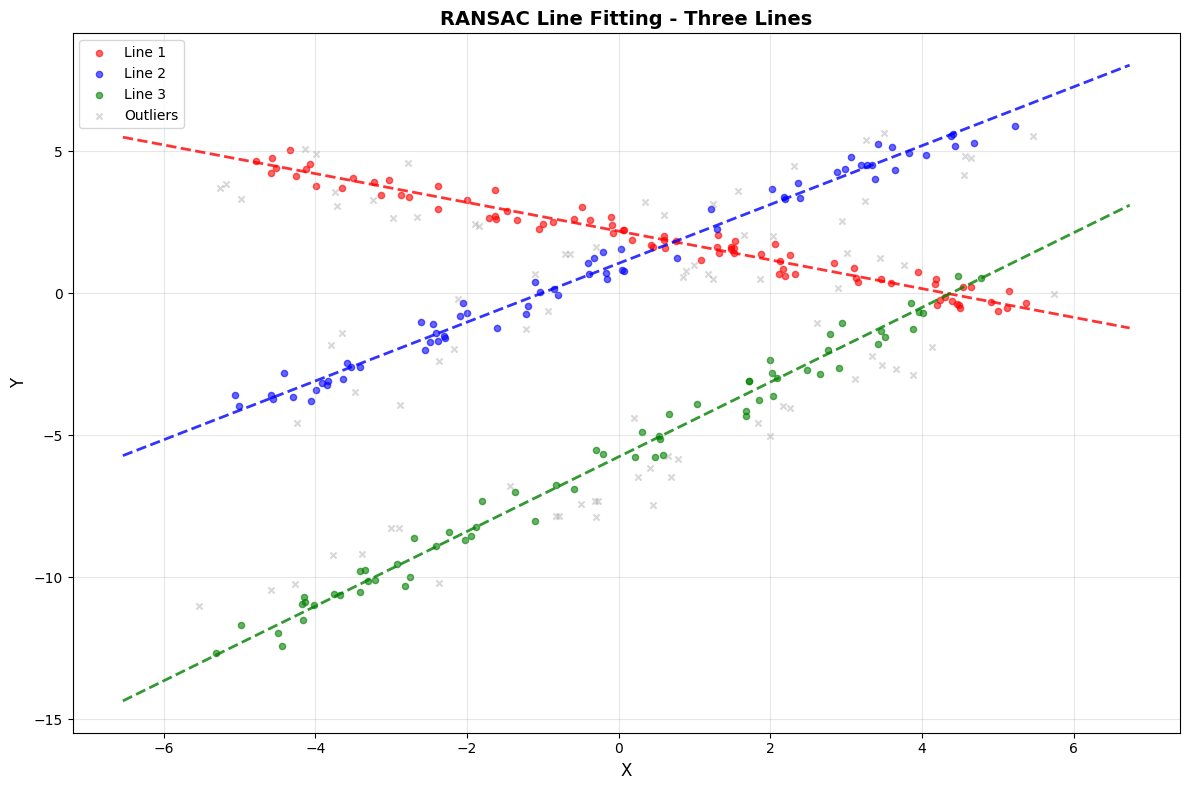


Total points assigned: 214
Outliers: 86


In [5]:
# Visualize the results
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# Plot points colored by which line they belong to
colors = ['red', 'blue', 'green']
labels = ['Line 1', 'Line 2', 'Line 3']

for i, (inliers, color, label) in enumerate(zip(all_inliers, colors, labels)):
    ax.scatter(X_all[inliers], Y_all[inliers], 
              c=color, s=20, alpha=0.6, label=label)

# Plot outliers (points not assigned to any line)
all_assigned = np.zeros(len(X_all), dtype=bool)
for inliers in all_inliers:
    all_assigned |= inliers
outliers = ~all_assigned
if np.sum(outliers) > 0:
    ax.scatter(X_all[outliers], Y_all[outliers], 
              c='gray', s=20, alpha=0.3, label='Outliers', marker='x')

# Plot the fitted lines
x_range = np.linspace(X_all.min() - 1, X_all.max() + 1, 100)
for i, (params, color) in enumerate(zip(lines, colors)):
    a, b, c = params
    if abs(b) > 1e-10:
        y_range = -(a * x_range + c) / b
        ax.plot(x_range, y_range, color=color, linewidth=2, 
               linestyle='--', alpha=0.8)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('RANSAC Line Fitting - Three Lines', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal points assigned: {np.sum(all_assigned)}")
print(f"Outliers: {np.sum(outliers)}")
